# **Load some needed libraries**

In [43]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.svm import SVC 
from sklearn.preprocessing import LabelEncoder, StandardScaler , RobustScaler
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_recall_curve, precision_score, confusion_matrix

# **Load and explore DataSet**

In [ ]:
df = pd.read_csv('crop_recommendation.csv')
df.head()

In [45]:
df.shape

(7000, 12)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nitrogen_mg_kg      7000 non-null   float64
 1   phosphorus_mg_kg    7000 non-null   float64
 2   potassium_mg_kg     7000 non-null   float64
 3   soil_ph             7000 non-null   float64
 4   organic_matter_pct  7000 non-null   float64
 5   temperature_avg_c   7000 non-null   float64
 6   humidity_pct        7000 non-null   float64
 7   rainfall_mm         7000 non-null   float64
 8   soil_type           7000 non-null   object 
 9   region              7000 non-null   object 
 10  season              7000 non-null   object 
 11  recommended_crop    7000 non-null   object 
dtypes: float64(8), object(4)
memory usage: 656.4+ KB


In [47]:
print(f"num of nulls : \n {df.isna().sum()}")
print(f"num of duplicates : {df.duplicated().sum()}")

num of nulls : 
 nitrogen_mg_kg        0
phosphorus_mg_kg      0
potassium_mg_kg       0
soil_ph               0
organic_matter_pct    0
temperature_avg_c     0
humidity_pct          0
rainfall_mm           0
soil_type             0
region                0
season                0
recommended_crop      0
dtype: int64
num of duplicates : 0


# **Detect Outliers**

In [48]:
num_col = df.select_dtypes(include=['int64','float64'])
cate_col = df.select_dtypes(include='object')

In [49]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    LB = Q1 - 1.5 * IQR
    UP = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < LB)  |  (df[col]  >  UP)].shape[0]
    
    print(f"--- {col} ---")
    print(f"{col} outlire : {outliers} , (LB: {LB:.2f}, UB: {UP:.2f})")
    print("-" * 30)

--- nitrogen_mg_kg ---
nitrogen_mg_kg outlire : 168 , (LB: 26.60, UB: 134.60)
------------------------------
--- phosphorus_mg_kg ---
phosphorus_mg_kg outlire : 0 , (LB: 12.40, UB: 62.00)
------------------------------
--- potassium_mg_kg ---
potassium_mg_kg outlire : 3 , (LB: 91.80, UB: 278.20)
------------------------------
--- soil_ph ---
soil_ph outlire : 0 , (LB: 5.10, UB: 8.30)
------------------------------
--- organic_matter_pct ---
organic_matter_pct outlire : 0 , (LB: 0.15, UB: 3.59)
------------------------------
--- temperature_avg_c ---
temperature_avg_c outlire : 0 , (LB: -1.15, UB: 51.25)
------------------------------
--- humidity_pct ---
humidity_pct outlire : 0 , (LB: 8.50, UB: 106.10)
------------------------------
--- rainfall_mm ---
rainfall_mm outlire : 497 , (LB: -21.30, UB: 43.50)
------------------------------


In [50]:
px.box(df['rainfall_mm'],
       color_discrete_sequence=['Green'],
       orientation="h",
       title="Rainfall Outlier")

In [51]:
num_col

,nitrogen_mg_kg,phosphorus_mg_kg,potassium_mg_kg,soil_ph,organic_matter_pct,temperature_avg_c,humidity_pct,rainfall_mm
0,59.3,38.5,170.4,7.20,1.400,33.7,44.1,3.9
1,92.0,34.2,211.4,7.20,1.900,34.0,51.7,3.2
2,78.5,37.0,197.1,7.40,1.700,16.2,59.7,44.3
3,96.8,40.8,214.5,6.90,2.000,21.9,61.2,1.6
4,21.4,36.2,112.4,6.59,1.470,14.5,76.1,50.4
...,...,...,...,...,...,...,...,...
6995,38.7,40.3,157.9,6.00,1.400,9.3,64.6,39.4
6996,61.0,27.7,142.7,6.33,2.289,26.1,50.1,4.7
6997,93.1,37.8,152.5,6.06,2.821,30.5,54.5,7.3
6998,94.7,37.7,179.3,6.00,2.200,31.7,75.8,4.3


In [52]:
df['recommended_crop'].unique()

array(['Cotton', 'Sugarcane', 'Wheat', 'Maize', 'Fava Beans', 'Rice',
       'Potato', 'Tomato'], dtype=object)

# **Encoding categorical features**

In [53]:
soil_map = {"Clay": 0, "Loamy": 1, "Calcareous": 2, "Sandy": 3}
region_map = {"Delta": 0, "Upper_Egypt": 1, "North_Coast": 2, "Sinai": 3, "NewLands": 4}
season_map = {"Winter": 0, "Summer": 1, "Nile": 2}
crop_map = {"Wheat": 0, "Maize": 1, "Cotton": 2, "Potato": 3, "Tomato": 4, "Sugarcane": 5, "Rice": 6, "Fava Beans": 7}

df['soil_type'] = df['soil_type'].map(soil_map)
df['region'] = df['region'].map(region_map)
df['season'] = df['season'].map(season_map)
df['recommended_crop'] = df['recommended_crop'].map(crop_map)

In [54]:
df.head()

,nitrogen_mg_kg,phosphorus_mg_kg,potassium_mg_kg,soil_ph,organic_matter_pct,temperature_avg_c,humidity_pct,rainfall_mm,soil_type,region,season,recommended_crop
0,59.3,38.5,170.4,7.20,1.40,33.7,44.1,3.9,0,0,1,2
1,92.0,34.2,211.4,7.20,1.90,34.0,51.7,3.2,1,1,2,5
2,78.5,37.0,197.1,7.40,1.70,16.2,59.7,44.3,3,0,0,0
3,96.8,40.8,214.5,6.90,2.00,21.9,61.2,1.6,1,2,1,1
4,21.4,36.2,112.4,6.59,1.47,14.5,76.1,50.4,0,2,0,7


# **Data Splitting**

In [55]:
x = df.drop('recommended_crop', axis=1)
y = df['recommended_crop']

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5600, 11)
(1400, 11)
(5600,)
(1400,)


In [57]:
robst = RobustScaler()
X_train_rob = robst.fit_transform(x_train)
X_test_rob = robst.transform(x_test)

# **Model Training**

In [58]:
param_grid = {
    'C':     [1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'poly']
}

grid = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_rob, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,SVC(class_wei...ndom_state=42)
,param_grid,"{'C': [1, 10, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'poly']}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


# **Model Evaluate**

In [59]:
print("Best Params:", grid.best_params_)
print("Best Score:", round(grid.best_score_, 4))

# التقييم بالأفضل
best_svc = grid.best_estimator_
y_pred = best_svc.predict(X_test_rob)
y_train_pred = best_svc.predict(X_train_rob)

print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

Best Params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Score: 0.9162
Train Accuracy: 0.9489
Test Accuracy: 0.93

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       157
           1       0.82      0.88      0.85       175
           2       0.99      0.99      0.99       195
           3       0.96      0.95      0.95       188
           4       0.86      0.76      0.81       176
           5       0.94      0.94      0.94       178
           6       0.90      0.95      0.92       167
           7       1.00      1.00      1.00       164

    accuracy                           0.93      1400
   macro avg       0.93      0.93      0.93      1400
weighted avg       0.93      0.93      0.93      1400



In [60]:
crop_names = ['Wheat', 'Maize', 'Cotton', 'Potato', 
              'Tomato', 'Sugarcane', 'Rice', 'Fava Beans']

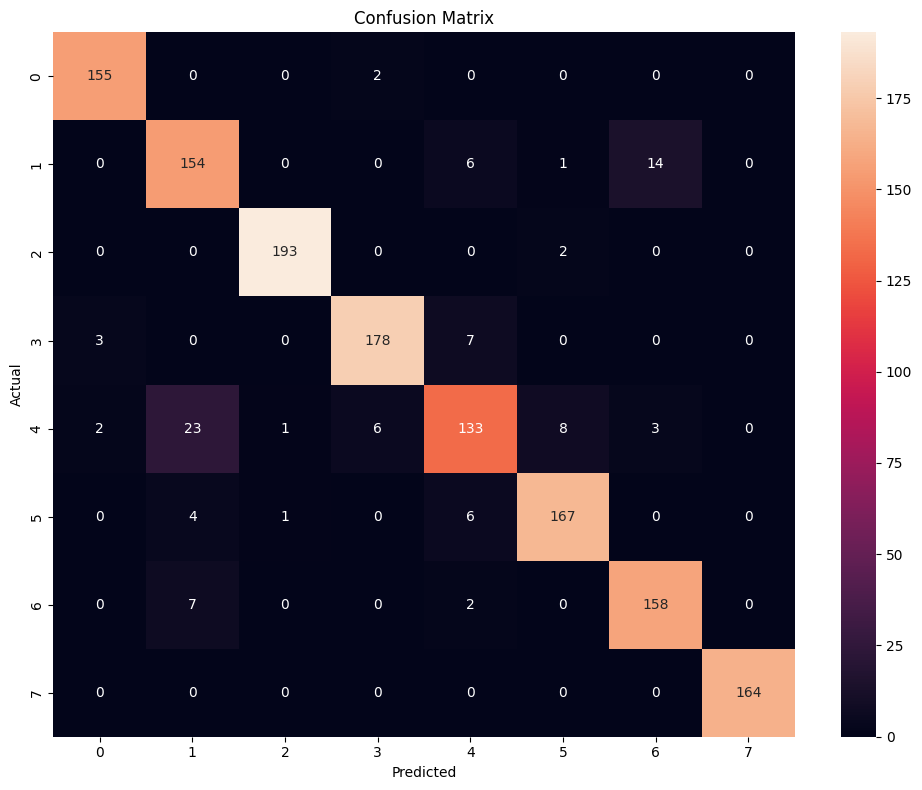

In [61]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()